In [1]:
import warnings
warnings.filterwarnings(action='ignore')

# 파워포인트 자동화

- 파워포인트도 엑셀, 워드 파일과 마찬가지로 Office Open XML(OOXML) 규약에 맞춰 저장됩니다.

# python-pptx

[python-pptx](https://python-pptx.readthedocs.io/en/latest/)

- python-pptx 패키지는 OOXML을 편집 수정할 수 있는 기능을 포함하고 있어 파이썬 코드만으로도 파워포인트 파일의 내용을 쉽게 변경할 수 있습니다.
- python-pptx를 pandas와 같은 데이터 핸들링 패키지와 함께 사용하면 더욱 효과적입니다.

## python-pptx 주요기능

- 파워포이트 파일의 읽기/쓰기 지원
- 슬라이드 추가 및 삭제, 글상자, 이미지, 표, 도형등 개체 추가 및 조정
- ppt 그래프 추가
- 파워포인트에서 사용하는 기능 대부분 지원

## python-pptx 설치

In [2]:
pip install python-pptx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------ --------------------- 3.4/7.2 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 17.4 MB/s  0:00:00

   ---------------------------------------- 0/3 [XlsxWriter]
   ------------- -------------------------- 1/3 [Pillow]
   ------------- -------------------------- 1/3 [Pillow]
   -------------------------- ------------- 2/3 [python-pptx]
   -------------------------- ------------- 2/3 [python-pptx]
   ---------------------------------------- 3/3 [python-pptx]

Note: you may need to restart the kernel to use updated packages.


## python-pptx 관련 핵심 객체별 주요 함수 정리

### 파워포인트 파일의 기본 구조

- Presentation: PPT 파일 전체를 의미합니다.
- Slide: 개별 슬라이드입니다. 슬라이드마다 '레이아웃'이 적용됩니다.
- Shape: 슬라이드 안에 들어가는 모든 요소(텍스트 박스, 그림, 표, 도형 등)를 의미합니다.
- TextFrame: 도형(Shape) 내부의 텍스트 영역을 의미합니다.
- Paragraph: 텍스트 프레임안에 엔터를 쳐서 구분되는 문단 단위를 의임합니다.
- Run: 하나의 문단 안에서 글꽃, 크기, 색상 등 스타일이 같은 최소 단위입니다.
  
### Presentation (prs) 관련: 파일 전체 관리
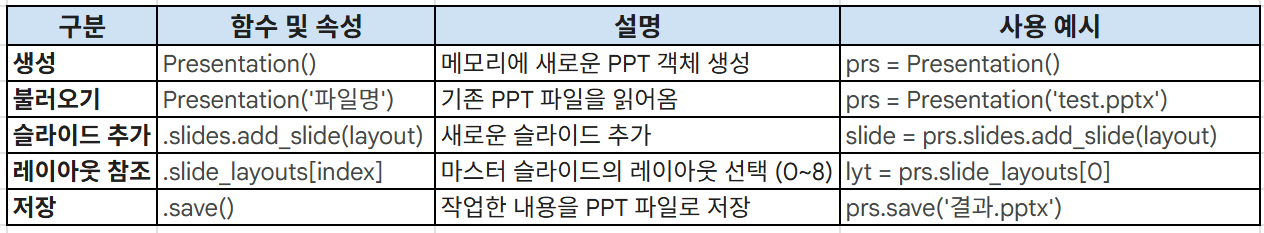

### Slide & Shape 관련: 슬라이드 구성 요소 관리
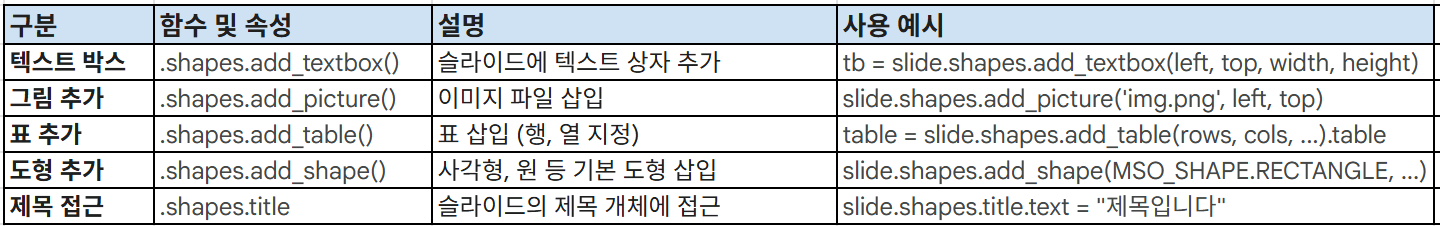

### Text (tf/p) 관련: 텍스트 및 서식 관리
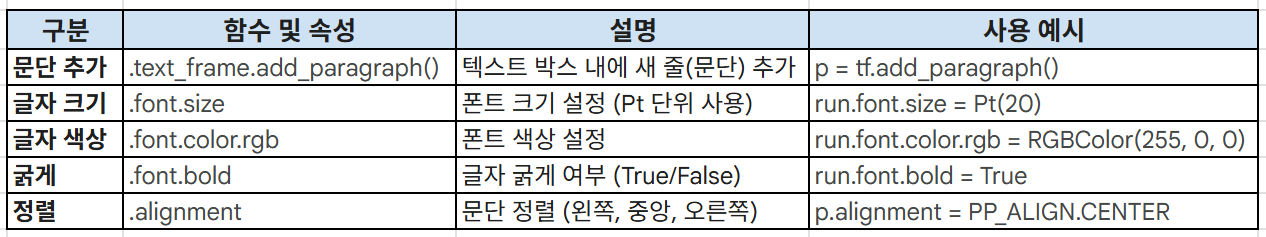

# 파일 생성 및 텍스트 추가하기

## 레이아웃 이해하고 파일 생성하기

- Presentation(): 메모리상에 새로운 파워포인트 문서 객체를 생성, 하나의 파워포인트 문서
- prs.slide_layouts: 객체에서 사용가능한 슬라이드 레이아웃 리스트
- prs.slides: 파워포인트 문서(Presentation) 내에 포함된 '모든 슬라이드들의 집합(Collection)'을 관리하는 객체
- prs.slides.add_slide(prs.slide_layouts[n]): 선택한 레이아웃으로 새 슬라이드 추가
- pre.save('파일명.pptx'): 작업한 내용을 파워포인트 파일로 저장

In [ ]:
from pptx import Presentation

# ppt 파일 생성
pre = Presentation()

# 첫 번째 슬라이드 레이아웃 선택
slide_layout = pre.slide_layouts[0]
print(slide_layout)

# 슬라이드 추가
slide = pre.slides.add_slide(slide_layout)

# 파일 생성
pre.save('pre.pptx')

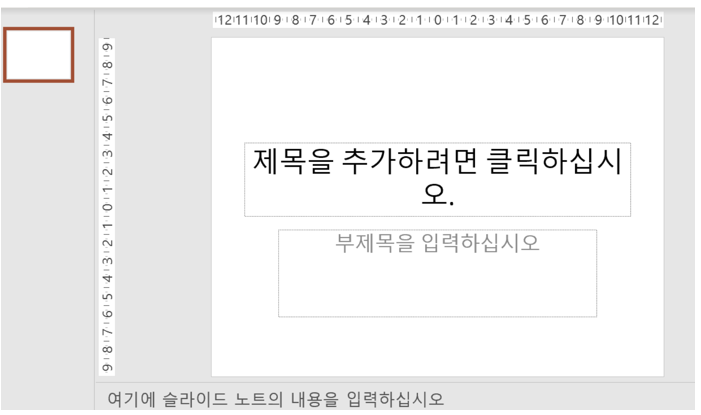

In [8]:
# 레이아웃 인덱스와 이름 출력하기
from pptx import Presentation

pre = Presentation()

for i, layout in enumerate(pre.slide_layouts) :
    print(f'Layout {i} : {layout.name}')

Layout 0 : Title Slide
Layout 1 : Title and Content
Layout 2 : Section Header
Layout 3 : Two Content
Layout 4 : Comparison
Layout 5 : Title Only
Layout 6 : Blank
Layout 7 : Content with Caption
Layout 8 : Picture with Caption
Layout 9 : Title and Vertical Text
Layout 10 : Vertical Title and Text


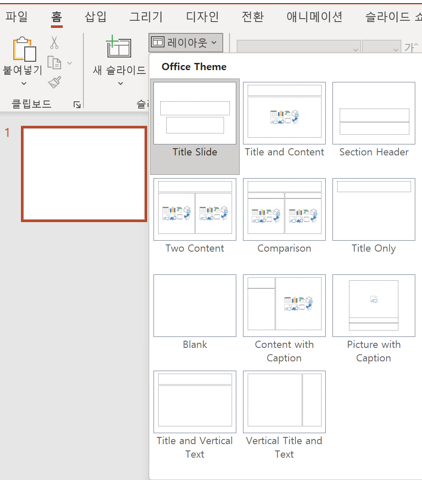

## 텍스트 추가하기

- slide.shapes: 슬라이드에 포함된 모든 도형이나 요소를 포함하는 속성, 여기에는 기본도형, 텍스트 박스, 이미지, 표, 차트, placeholder도 포함
- 슬라이드에 추가되는 모드 요소는 shapes 속성에 포함되기 때문에 , shapes를 사용해 슬라이드에 새로운 요소를 추가할 수 도 있고 기존 요소를 다룰 수도 있습니다.
- slide.placeholders: placeholder란 슬라이드 상에서 내용이 들어갈 자리를 미리 지정해 놓을 것으로 텍스트나 이미지, 차트 등 다양한 콘텐츠를 넣을 수 있는 공간 또는 틀 (이미 만들어져 있는것)
- slide.shapes.title: 슬라이드 레이아웃에서 '제목' 역할로 정의된 특정한 개체 틀(Placeholder)을 가리키며, 슬라이드의 핵심 주제를 입력하기 위해 가장 우선적으로 접근하는 속성

In [11]:
from pptx import Presentation

pre = Presentation()

slide = pre.slides.add_slide(pre.slide_layouts[0])

# 슬라이드 제목 placeholders에 접근해서 텍스트 입력
title = slide.placeholders[0]
title.text = 'Hello World !!!'

# 슬라이드 부제목 placeholders에 접근해서 텍스트 입력
subtitle = slide.placeholders[1]
subtitle.text = '파워포인트 자동화'

pre.save('pre.pptx')

In [12]:
# 특정 레이아웃의 placeholder[인덱스]와 역할을 알아내기
from pptx import Presentation

pre = Presentation()

slide_layout = pre.slide_layouts[0]
print(slide_layout)

slide = pre.slides.add_slide(slide_layout)

for i, placeholder in enumerate(slide.placeholders) :
    print(f'플레이스홀더 {i} : {placeholder.name}')

플레이스홀더 0 : Title 1
플레이스홀더 1 : Subtitle 2


## 텍스트 박스 추가하고 텍스트 추가하기

- slide.shapes.add_textbox(): 슬라이드에 새 텍스트 박스를 추가
- textbox.text_frame.add_paragraph(): 텍스트 박스에 텍스트를 추가할 때는 텍스트 박스에 바로 문자열을 전달하는게 아니라 텍스트 박스의 텍스트 프레임을 이용

In [14]:
from pptx import Presentation
from pptx.util import Inches


pre = Presentation()
slide = pre.slides.add_slide(pre.slide_layouts[1])
title = slide.shapes.title
subtitle = slide.placeholders[1]

title.text = '제목'
subtitle.text = '부제목'

left = Inches(1)
top = Inches(2)
width = Inches(5)
height = Inches(1.5)

textbox = slide.shapes.add_textbox(left=left, top=top, width=width, height=height)

frame = textbox.text_frame
p = frame.add_paragraph()
p.text = '새로운 텍스트 박스에 추가된 텍스트'

pre.save('pre_add_text.pptx')

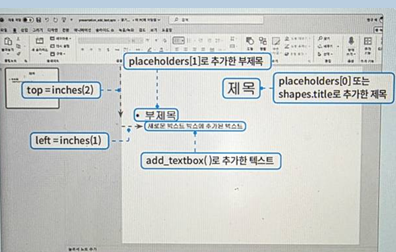

## 목록 추가하기

- 목록은 Paragraph 객체에 level 속성을 사용

In [16]:
from pptx import Presentation

prs = Presentation()
slide_layout = prs.slide_layouts[1] 

slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '파이썬의 장점'

# placeholder 1의 첫번째 항목
tf = slide.placeholders[1].text_frame
tf.text = '쉬운 사용법'

# 첫번째 항목의 하위항목 추가
p = tf.add_paragrapth()
p.text = '직관적인 문법'
p.level = 1

# 두번째 항목
p = tf.add_paragrapth()
p.text = '높은 생산성'
p.level = 0

# 두번째 항목의 하위항목 추가
p = tf.add_paragrapth()
p.text = '빠른 개발 속도'
p.level = 1

# 세번째 항목
p = tf.add_paragrapth()
p.text = '다양한 라이브러리와 프레임워크'
p.level = 0

# 세번째 항목의 하위항목 추가
p = tf.add_paragrapth()
p.text = '머신러닝, 웹 개발 등에 유용'
p.level = 1

prs.save('pre_with_list.pptx')

AttributeError: 'TextFrame' object has no attribute 'add_paragrapth'

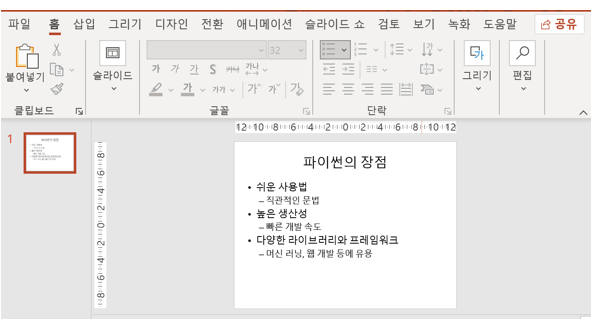

## 텍스트 서식 설정하기

- 파워포인트 텍스트 계층 구조
  
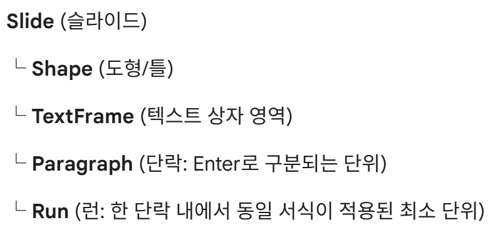

- Shape, paragraph, run 수준으로 텍스트 서식 설정 가능합니다.

In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from pptx.dml.color import RGBColor 

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '서식 설정하기'



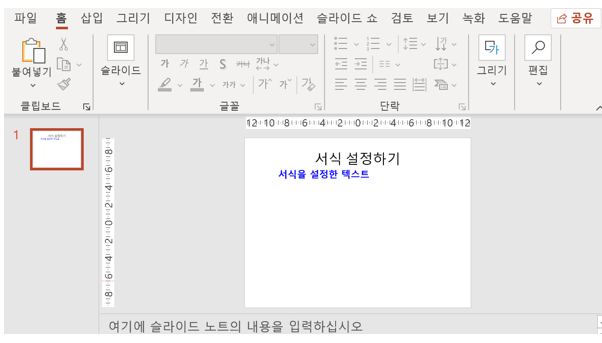

## 개별 텍스트에 서식 설정하기

In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from pptx.dml.color import RGBColor 

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '서식 설정하기'





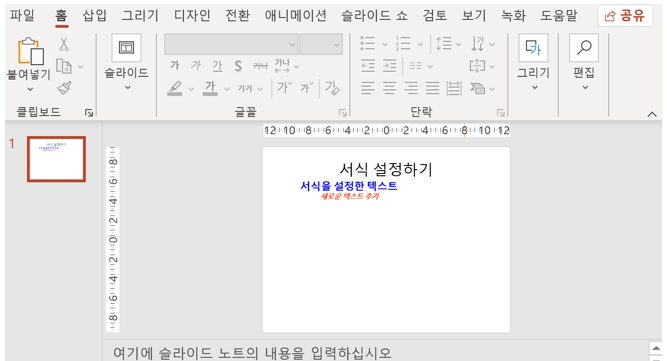

## 표 추가하기

- slide.shapes.add_table(): 테이블 생성, GraphicFrame이라는 객체를 만들고 그 안에 표 생성하므로 GraphicFrame 객체 반환, GraphicFrame.table 속성을 사용해서 접근

In [ ]:
from pptx import Presentation
from pptx.util import Inches

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '표 추가하기'

# 표 추가 위치 및 크기, 행과 열의 개수 설정
left = Inches(2)
top = Inches(2)
width = Inches(6)
height = Inches(4.5)
rows, cols = 3, 2

# 표 추가 (3행 2열)


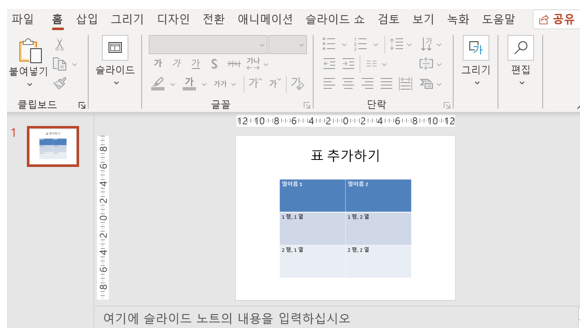

## 표 서식 설정하기

In [ ]:
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
from pptx.dml.color import RGBColor
from pptx import Presentation
from pptx.util import Inches

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '표 추가하기'

# 표 추가 위치 및 크기, 행과 열의 개수 설정
left = Inches(2)
top = Inches(2)
width = Inches(6)
height = Inches(4.5)
rows, cols = 3, 2

# 표 추가 (3행 2열)


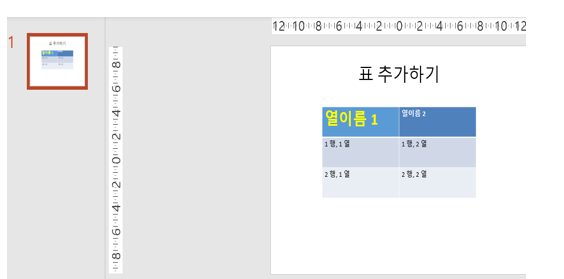

# 그래픽 요소 추가하기

- 도형, 이미지, 차트 등 그래픽 요소 추가

## 도형 추가하기

- shapes.add_shape(pptx.enum.shapes.MSO_SHAPE, left, top, width, height): 도형 생성
- pptx.enum.shapes.MSO_SHAPE: Microcoft Office 에서 사용할 수 있는 각종 그래픽 요소들을 정의
- 
  https://python-pptx.readthedocs.io/en/latest/api/enum/MsoAutoShapeType.html

In [ ]:
from pptx import Presentation
from pptx.util import Inches
from pptx.util import Pt
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '도형 추가하기'

# 둥근 직사각형을 추가

#  도형의 서식 설정


# 텍스트를 추가 후 서식 설정




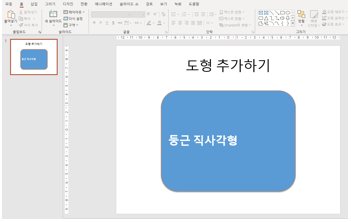

## 이미지 추가하기

- shapes.add_picture(img_path, left, top, width, height): 이미지 생성

In [ ]:
from pptx import Presentation
from pptx.util import Inches

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "이미지 추가하기"

# 이미지 경로 지정
img_path = './data/image1.png'

# 이미지의 위치와 크기 지정


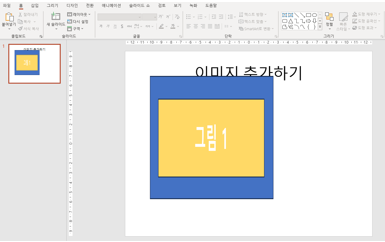

## 차트 추가하기

- CategoryChartData(): 차트 데이터를 담을 객체를 생성합니다.
- 차트객체.categories: 차트의 X축에 표시될 항목 이름(레이블)들을 리스트 형태로 설정합니다.
- 차트객체.add_series('이름', (데이터)): 차트에 표시될 범례 이름과 실제 수치 데이터(튜플/리스트)를 추가합니다.
- slide.shapes.add_chart(차트 종류, x, y, cx, cy, 데이터) : 슬라이드에 차트를 추가하는 핵심 함수입니다.
    - XL_CHART_TYPE.COLUMN_CLUSTERED: 수직 막대 차트
- slide.shapes.add_chart().chart 로 차트에 접근
    - .has_title: 차트 제목의 표시 여부를 결정하며, True로 설정해야 제목 수정이 가능해집니다.    
    - .chart_title: 차트의 상단 제목 객체로, .text_frame.text를 통해 실제 문구를 입력합니다.    
    - .category_axis: 항목 이름(A제품, B제품 등)이 표시되는 X축(가로축) 객체를 관리합니다.    
    - .value_axis: 수치 데이터(9.2, 11.4 등)가 표시되는 Y축(세로축) 객체를 관리합니다.    
    - .axis_title: X축이나 Y축이 무엇을 의미하는지 설명하는 축 제목 객체입니다.

In [ ]:
from pptx import Presentation
from pptx.chart.data import CategoryChartData
from pptx.enum.chart import XL_CHART_TYPE
from pptx.util import Inches

prs = Presentation()
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = '차트 추가하기'

# 차트 데이터 정의
chart_data = CategoryChartData() #  CategoryChartData 클래스 객체 생성
chart_data.categories = ['A제품', 'B제품', 'C제품'] # 카테고리 레이블 설정
chart_data.add_series('잔류오염도', (9.2, 11.4, 16.7)) # 데이터 시리즈 추가
# chart_data.add_series('잔류오염도2', (2.2, 6.4, 23.7)) #  데이터 시리즈 추가(테스트용)

#  차트의 위치 및 크기 지정
x, y, cx, cy = Inches(2), Inches(2), Inches(6), Inches(4.5)

#  차트 추가


# 차트 제목 설정


# x축과 y축 제목 설정


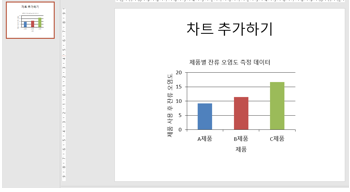

<u>차트 유형</u>

In [ ]:
from pptx.enum.chart import XL_CHART_TYPE

#print(dir(XL_CHART_TYPE))

# 차트 유형 나열
chart_types = [attr for attr in dir(XL_CHART_TYPE) 
               if not callable(getattr(XL_CHART_TYPE, attr)) and not attr.startswith('__')]
# not callable(getattr(XL_CHART_TYPE, attr)) 호출가능하지 않은 것 함수 제외 속성만
# 이름이 __(언더바 두 개)로 시작하는 것들을 제외, 시스템 내부적으로 사용하는 매직 매서드 제외
#
for chart_type in chart_types:
  print(chart_type)

# 파워포인트 파일 읽기

## 파일 열기

- 이미 만들어진 파워포인트 파일을 읽어와서 수정하거나 데이터를 추출

In [ ]:
from pptx import Presentation

# 파일 열기
prs = Presentation('./data/presentation_with_list.pptx')

## 텍스트 추출하기

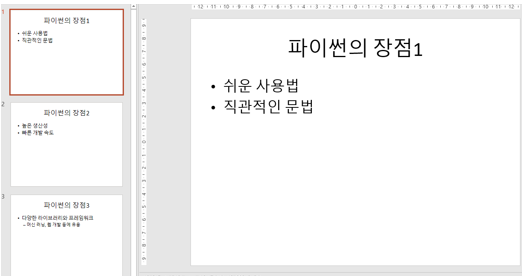

In [ ]:
from pptx import Presentation

prs = Presentation('./data/presentation_with_list.pptx') # 제공된 예제로 사용

# 각 슬라이드의 텍스트를 출력


## 표 읽어 추출하기

In [ ]:
from pptx import Presentation

prs = Presentation('./data/presentation_with_table.pptx')

# 전체 슬라이드를 순회하며 표를 찾아 데이터를 추출


## 이미지 파일 추출하기

In [ ]:
from pptx import Presentation

prs = Presentation('./data/presentation_with_image.pptx')

# 전체 슬라이드를 순회
for slide_number, slide in enumerate(prs.slides):
  # 각 슬라이드에서 모든 도형을 순회
  

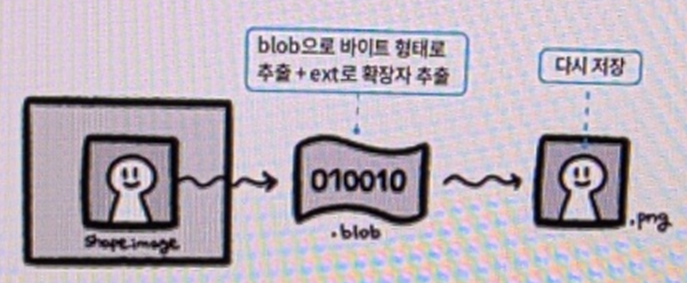

## 차트 데이터 추출하기

<u>zip( ) 함수란?</u>

In [ ]:
fruits = ['사과', '바나나', '메론']
colors = ['빨강', '노랑']
for fruit, color in zip(fruits, colors):
  print(fruit, color)

In [ ]:
from pptx import Presentation

prs = Presentation('./data/presentation_with_chart.pptx')

#  전체 슬라이드를 순회
for slide_number, slide in enumerate(prs.slides):

  # 각 슬라이드 내의 모든 도형을 순회
  

# [실습] 행사 참가자 명찰 제작하기

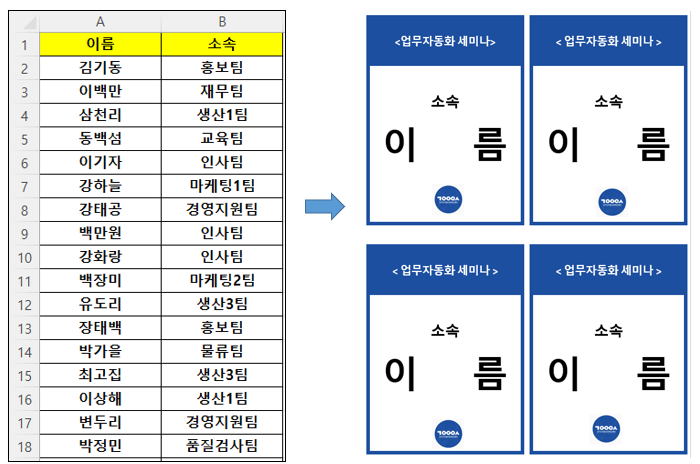

In [ ]:
from pptx import Presentation
from openpyxl import load_workbook

# 1. 경로 설정
excel_path = "./data/행사 참석자 명단.xlsx"
template_path = "./data/명찰 양식.pptx"
output_path = "./data/명찰_최종_완성본.pptx"

# 2. 엑셀 읽기


# 3. PPT 열기

# 4. 명찰 생성


# 5. 저장


# [실습] 엑셀과 조합하여 파워포인트 생성하기


- 제품별 판매내역.xlsx 엑셀 파일의 데이터로 파워포인트 자료를 만듦

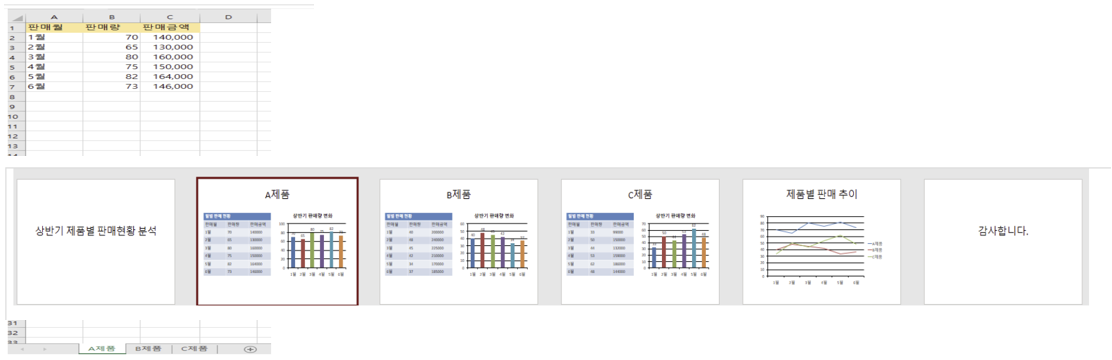

## 필요한 모듈과 클래스 불러오기

In [ ]:
from openpyxl import load_workbook # 엑셀 파일 작업
from pptx import Presentation # 파워포인트 파일 작업
from pptx.util import Inches # 객체를 인치로 지정
from pptx.enum.chart import XL_CHART_TYPE # 차트 유형
from pptx.chart.data import CategoryChartData # 차트 데이터 추가 클래스

## 엑셀 데이터 불러온 다음 파워포인트 객체 생성하기

In [ ]:
# 엑셀 파일에서 데이터 불러오기


# 파워포인트 객체 생성


# 표지 슬라이드 추가


## 판매량 데이터 가져오기

## 제품별 슬라이드 추가하고 표 생성하기

## 제품별 슬라이드에 차트 추가하기

## 전체 판매 추이 슬라이드에 선 차트 추가하기

## 마무리 슬라이드 추가한 다음 파일 저장하기